# 6.1 — K-Means Clustering

## The Big Idea

Every algorithm until now had **labels** — spam/not-spam, house price, survived/not-survived. The model learned by comparing its guesses to the right answers.

**K-Means has no labels. No right answers. No teacher.**

You throw raw data at it and say: *"Find the groups yourself."*

### Analogy — the hostel observation

Imagine you're a new student in a Kochi college hostel. Nobody tells you who's friends with whom. But after a week, you notice naturally: *these 5 guys always eat together, those 4 always play cricket, that group always studies together.* You found **groups without anyone labelling them.**

That's clustering.

### The Real World Problem

**Meena** is the marketing head at **FreshMart** — a supermarket chain with 6 branches across Kochi. She has data on 500 customers from their loyalty card program.

She says: *"I have ₹50,000 marketing budget. I don't want to send the same offer to everyone. A customer who spends ₹15,000/month doesn't need a ₹50 discount coupon. Help me find natural groups so I can target them properly."*

**No labels. No pre-defined groups. Just raw customer data.**

## How K-Means Works — Step by Step

Say K = 3 (we want 3 clusters).

**Step 1 — Initialise:** Pick 3 random points as **centroids** (the "centre" of each cluster).  
**Step 2 — Assign:** For every customer, calculate distance to all 3 centroids. Assign to the nearest one.  
**Step 3 — Update:** For each cluster, calculate the **mean** of all assigned points. That mean = new centroid.  
**Step 4 — Repeat:** Go back to Step 2. Reassign. Recalculate. Repeat.  
**Step 5 — Stop:** When centroids stop moving. Algorithm has **converged.**

### Why the mean minimises inertia (the WHY behind Step 3)

The mean is not just "probably the centre" — it is the **mathematically provable minimum** of the sum of squared distances.

For points 2, 4, 9 — the value `c` that minimises `(2-c)² + (4-c)² + (9-c)²` is **always the mean = 5**. No other value gives smaller total squared distance. Take the derivative, set to zero — you always get the mean.

This is why the algorithm is called **K-Means** — the update step literally uses the mean.

### What K-Means minimises — Inertia (WCSS)

```
Inertia = Σ (distance from each point to its cluster centroid)²
```

Lower inertia = tighter, more compact clusters. Every iteration is guaranteed to reduce (or maintain) inertia.

### Why it may not find the BEST solution

The random starting centroids **lock in a trajectory**. Every step after is mathematically perfect — but you're optimising from wherever you started. A bad random start → converge to a **local minimum**, not the global best.

**Fix:** sklearn runs K-Means `n_init=10` times with different random starts, keeps the best (lowest inertia). Also uses **K-Means++** initialisation — spreads starting centroids far apart to reduce bad starts.

## Key Concepts Table

| Concept | What it means |
|---|---|
| Centroid | Mean of all points in a cluster — the "centre" |
| Inertia / WCSS | Sum of squared distances from each point to its centroid — K-Means minimises this |
| Convergence | When centroids stop moving — algorithm is done |
| Local minimum | A decent solution that isn't the global best — caused by bad random start |
| K-Means++ | Smart initialisation — spreads starting centroids far apart to reduce local minima |
| n_init | How many random restarts sklearn does — picks result with lowest inertia |
| Elbow Method | Plot inertia vs K — look for the bend to pick best K |
| Silhouette Score | How well each point fits its own cluster vs neighbours — higher is better (-1 to +1) |
| Why scale | Large-scale features dominate distance calculation — StandardScaler mandatory |

In [1]:
# --- Imports ---
# numpy: generate synthetic customer data
# pandas: tabular view of clusters
# matplotlib/seaborn: visualise clusters and elbow/silhouette plots
# KMeans: the clustering algorithm
# StandardScaler: mandatory before KMeans — prevents large-scale features dominating distance
# silhouette_score: measures how well each point fits its cluster
# PCA: compress 4 features → 2D so we can plot clusters visually

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# reproducibility — same random seed = same synthetic data every run
np.random.seed(42)

print("Imports done.")

Imports done.


## Step 1 — Generate the Dataset

500 FreshMart customers with 4 features:
- `annual_income_k` — annual income in ₹ thousands (e.g. 480 = ₹4.8 lakh/year)
- `spending_score` — FreshMart's internal score 1–100 based on purchase amount and frequency
- `visit_frequency` — average visits per month
- `avg_basket_size` — average ₹ spent per visit

We build 3 natural groups so we can verify K-Means finds them:

In [2]:
# --- Generate 3 natural customer groups ---
# Each group has a different "centre" in feature space
# np.random.multivariate_normal generates points around that centre with some spread

n = 500

# Group 1 — Budget Regulars
# Low income, low spending score, high visit frequency, small basket
# These are loyal, price-sensitive customers who come often but spend little per visit
g1 = np.random.multivariate_normal(
    mean=[250, 25, 12, 400],       # centre: ₹2.5L income, score 25, 12 visits, ₹400/visit
    cov=np.diag([30**2, 8**2, 3**2, 80**2]),  # spread around centre
    size=180
)

# Group 2 — Occasional Affluent
# High income, high spending score, low visits, large basket
# Come rarely but spend a lot per visit — premium shoppers
g2 = np.random.multivariate_normal(
    mean=[800, 75, 3, 2500],       # centre: ₹8L income, score 75, 3 visits, ₹2500/visit
    cov=np.diag([80**2, 10**2, 1**2, 400**2]),
    size=160
)

# Group 3 — Young Mid-Spenders
# Mid income, moderate spending, moderate visits
# Probably young professionals — respond to deals and new products
g3 = np.random.multivariate_normal(
    mean=[480, 55, 7, 1100],       # centre: ₹4.8L income, score 55, 7 visits, ₹1100/visit
    cov=np.diag([50**2, 12**2, 2**2, 200**2]),
    size=160
)

# Stack all groups into one array — K-Means will receive this without group labels
X_raw = np.vstack([g1, g2, g3])

# Convert to DataFrame for readability
df = pd.DataFrame(X_raw, columns=['annual_income_k', 'spending_score', 'visit_frequency', 'avg_basket_size'])

# Clip to realistic bounds — no negative income or visits
df['annual_income_k'] = df['annual_income_k'].clip(100, 1200)
df['spending_score']  = df['spending_score'].clip(1, 100)
df['visit_frequency'] = df['visit_frequency'].clip(1, 20)
df['avg_basket_size'] = df['avg_basket_size'].clip(100, 5000)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (500, 4)


,annual_income_k,spending_score,visit_frequency,avg_basket_size
0,245.852071,30.181508,16.569090,439.737132
1,242.975891,37.633703,14.302304,381.267730
2,266.276801,21.292658,10.602811,362.442049
3,192.601593,11.200657,10.313137,419.356982
4,259.427420,17.735807,7.763089,318.973510


## Step 2 — EDA (Exploratory Data Analysis)

Before clustering, understand the data. Check distributions and correlations.

In [3]:
# --- Basic stats ---
# Do any features have wildly different scales? (They do — income in hundreds vs score 1-100)
# This confirms StandardScaler is mandatory before K-Means
print("=== Basic Statistics ===")
df.describe().round(2)

=== Basic Statistics ===


,annual_income_k,spending_score,visit_frequency,avg_basket_size
count,500.00,500.00,500.00,500.00
mean,502.73,51.02,7.59,1313.03
std,234.52,23.37,4.30,932.16
min,191.21,1.00,1.00,187.92
25%,264.21,28.27,3.69,427.39
50%,478.82,52.88,7.14,1078.82
75%,723.93,71.95,10.60,2249.53
max,1006.38,100.00,20.00,3510.77


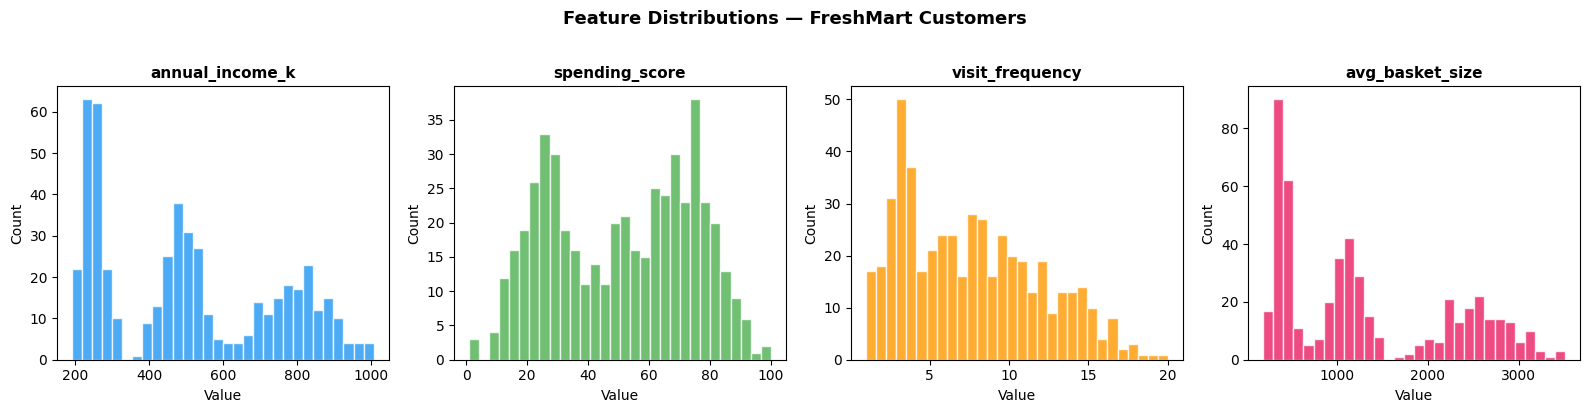

Notice: annual_income_k ranges 100-1200, avg_basket_size ranges 100-5000.
spending_score is only 1-100. Without scaling, income and basket dominate distance.


In [4]:
# --- Distribution plots ---
# Why: K-Means uses distance. If one feature has a much larger range,
# it dominates the distance calculation unfairly.
# Looking at distributions tells us if scaling is urgently needed.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
features = ['annual_income_k', 'spending_score', 'visit_frequency', 'avg_basket_size']
colors   = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for ax, feat, color in zip(axes, features, colors):
    ax.hist(df[feat], bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions — FreshMart Customers', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Notice: annual_income_k ranges 100-1200, avg_basket_size ranges 100-5000.")
print("spending_score is only 1-100. Without scaling, income and basket dominate distance.")

## Step 3 — Scaling (Mandatory before K-Means)

K-Means uses **Euclidean distance**:
```
distance = √( (income_A - income_B)² + (score_A - score_B)² + ... )
```

If `income` differs by 500 (₹5L gap) but `spending_score` differs by 30 — the income difference is **16x larger** and completely drowns out the spending score in the distance calculation. The clustering would be based almost entirely on income, ignoring other features.

`StandardScaler` transforms every feature to mean=0, std=1:
```
x_scaled = (x - mean) / std
```
Now all features contribute equally to distance.

In [5]:
# --- StandardScaler ---
# fit() computes mean and std of each feature FROM TRAINING DATA ONLY
# transform() applies (x - mean) / std to each value
# Here there's no train/test split (unsupervised) — we fit on the full dataset

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Verify: after scaling, every feature should have mean≈0 and std≈1
print("After scaling:")
print(f"  Means: {X_scaled.mean(axis=0).round(4)}")
print(f"  Stds:  {X_scaled.std(axis=0).round(4)}")
print("\nAll features now on equal footing — fair distance calculation.")

After scaling:
  Means: [ 0. -0.  0. -0.]
  Stds:  [1. 1. 1. 1.]

All features now on equal footing — fair distance calculation.


## Step 4 — Finding the Right K

### Method 1: Elbow Method

Run K-Means for K = 1 to 10. Record inertia each time. Plot. Look for the "elbow" — where adding more clusters gives diminishing returns.

### Method 2: Silhouette Score

For each point, measures:
- **Cohesion (a):** average distance to other points in its own cluster
- **Separation (b):** average distance to points in the nearest other cluster

```
silhouette = (b - a) / max(a, b)
```

Ranges -1 to +1. Higher = better. Pick K with highest average silhouette score.

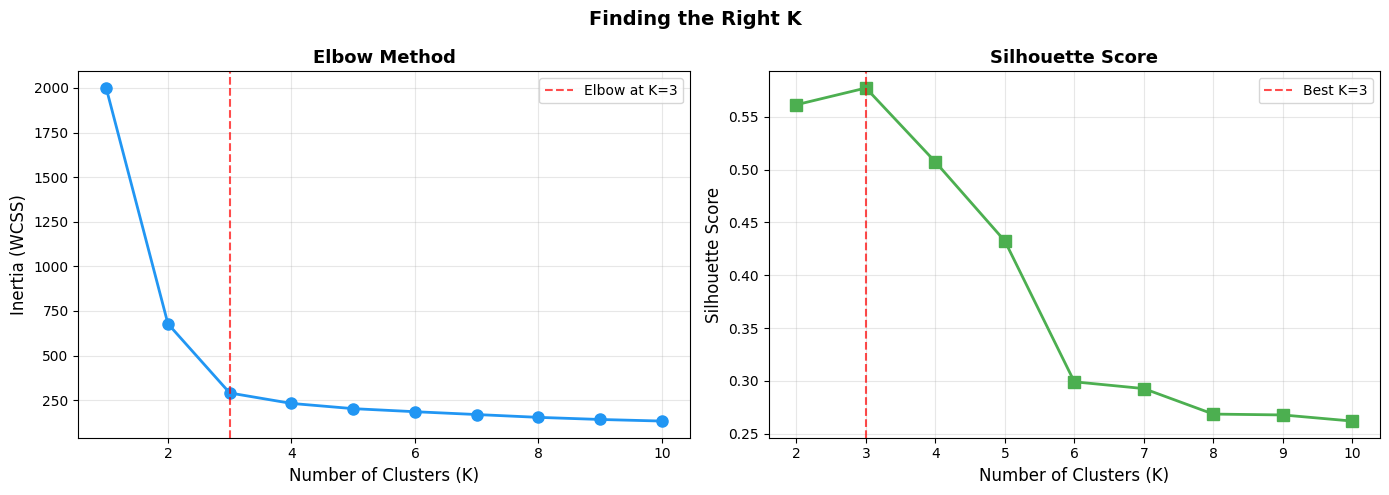

Elbow suggests: K=3
Silhouette suggests: K=3 (score=0.577)
Both agree → K=3


In [7]:
# --- Elbow Method + Silhouette Score ---
# Why run both: elbow shows diminishing returns, silhouette measures actual cluster quality
# When both agree on a K — that's a strong signal

inertias = []
silhouette_scores = []
K_range = range(2, 11)  # silhouette undefined for K=1 (need at least 2 clusters)

for k in K_range:
    # n_init=10: run 10 times with different random starts, keep best (lowest inertia)
    # init='k-means++': spread initial centroids far apart — reduces bad local minima
    # random_state=42: reproducibility
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    
    inertias.append(km.inertia_)          # sum of squared distances to centroids
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))  # cluster quality

# Add K=1 inertia separately for elbow plot (silhouette not defined)
km1 = KMeans(n_clusters=1, n_init=10, random_state=42).fit(X_scaled)
all_inertias = [km1.inertia_] + inertias

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(range(1, 11), all_inertias, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Elbow at K=3')
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Silhouette score plot
ax2.plot(list(K_range), silhouette_scores, 's-', color='#4CAF50', linewidth=2, markersize=8)
best_k = list(K_range)[np.argmax(silhouette_scores)]
ax2.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Finding the Right K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Elbow suggests: K=3")
print(f"Silhouette suggests: K={best_k} (score={max(silhouette_scores):.3f})")
print(f"Both agree → K=3")

## Step 5 — Train K-Means with K=3

In [8]:
# --- Train final K-Means ---
# K=3 chosen from elbow + silhouette agreement
# init='k-means++': smart centroid initialisation — spreads them far apart
#   Why: random init can place two centroids in the same dense region → bad clustering
#   K-Means++ picks 1st centroid randomly, then each next centroid with prob proportional
#   to distance² from existing centroids — forces spread
# n_init=10: run 10 times, keep best result — guards against local minima
# max_iter=300: maximum iterations before stopping even if not converged
# random_state=42: same result every run

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
kmeans.fit(X_scaled)

# .labels_: cluster assignment for every customer (0, 1, or 2)
# These numbers are arbitrary — 0 is not "better" than 2
# Meaning comes from analysing what each cluster looks like
df['cluster'] = kmeans.labels_

print(f"Inertia (final): {kmeans.inertia_:.2f}")
print(f"Iterations to converge: {kmeans.n_iter_}")
print(f"\nCustomers per cluster:")
print(df['cluster'].value_counts().sort_index())

Inertia (final): 290.19
Iterations to converge: 7

Customers per cluster:
cluster
0    160
1    181
2    159
Name: count, dtype: int64


## Step 6 — Analyse Clusters

The cluster numbers (0, 1, 2) are meaningless on their own. Meaning comes from looking at what each cluster actually looks like — what are the average values of each feature per cluster?

In [9]:
# --- Cluster profiles ---
# Group by cluster, compute mean of every feature
# This tells us: what does a "typical" customer in each cluster look like?
profile = df.groupby('cluster')[['annual_income_k', 'spending_score', 
                                   'visit_frequency', 'avg_basket_size']].mean().round(1)
print("=== Cluster Profiles (Original Scale) ===")
print(profile)

# Map cluster numbers to human-readable names based on profiles
# We look at the profile and assign names ourselves — K-Means doesn't name clusters
# This manual step is always required in real unsupervised projects
cluster_names = {}
for c in range(3):
    row = profile.loc[c]
    if row['annual_income_k'] < 400:
        cluster_names[c] = 'Budget Regulars'
    elif row['annual_income_k'] > 600:
        cluster_names[c] = 'Occasional Affluent'
    else:
        cluster_names[c] = 'Young Mid-Spenders'

df['segment'] = df['cluster'].map(cluster_names)

print("\n=== Cluster Names ===")
for c, name in cluster_names.items():
    print(f"  Cluster {c} → {name}")

=== Cluster Profiles (Original Scale) ===
         annual_income_k  spending_score  visit_frequency  avg_basket_size
cluster                                                                   
0                  800.8            75.7              3.1           2553.5
1                  251.9            25.0             12.0            398.7
2                  488.4            55.9              7.1           1105.6

=== Cluster Names ===
  Cluster 0 → Occasional Affluent
  Cluster 1 → Budget Regulars
  Cluster 2 → Young Mid-Spenders


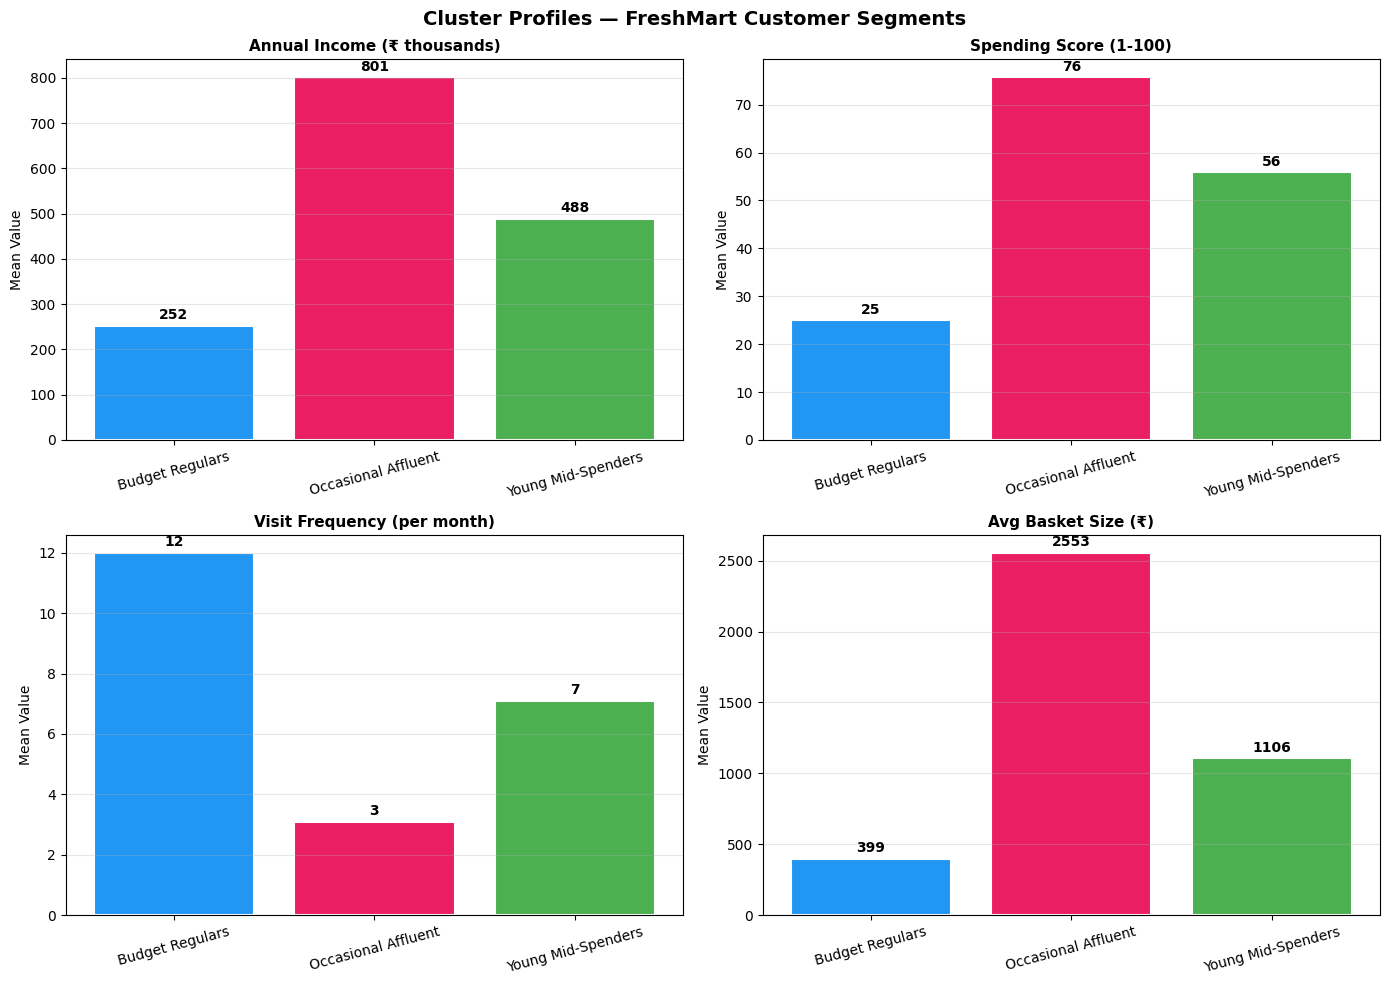

In [10]:
# --- Visual cluster profiles ---
# Bar chart for each feature, grouped by cluster
# Why: a table of numbers is harder to interpret than a visual

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
segment_colors = {'Budget Regulars': '#2196F3', 
                  'Occasional Affluent': '#E91E63', 
                  'Young Mid-Spenders': '#4CAF50'}

features_to_plot = ['annual_income_k', 'spending_score', 'visit_frequency', 'avg_basket_size']
titles = ['Annual Income (₹ thousands)', 'Spending Score (1-100)', 
          'Visit Frequency (per month)', 'Avg Basket Size (₹)']

for ax, feat, title in zip(axes.flatten(), features_to_plot, titles):
    means = df.groupby('segment')[feat].mean()
    bars = ax.bar(means.index, means.values, 
                  color=[segment_colors[s] for s in means.index],
                  edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Value')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    # Add value labels on bars
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(means)*0.01,
                f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Cluster Profiles — FreshMart Customer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7 — Visualise Clusters with PCA

We have 4 features — impossible to plot in 4D. 

**PCA (Principal Component Analysis)** compresses 4 features → 2 components that capture the most variance. Think of it as finding the 2 best angles to view the data from. We'll study PCA fully in 6.4 — here we use it purely as a visualisation tool.

In [11]:
# --- PCA for 2D visualisation ---
# n_components=2: compress 4 features → 2 dimensions
# Why 2: we can plot 2D. 3D is possible but harder to read.
# PCA finds the 2 directions of maximum variance — the 2 axes along which data varies most
# We lose some information but keep the most important structure

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  Component 1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  Component 2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print("\nWe keep most of the information — clusters will still be visible.")

Variance explained by 2 components: 93.6%
  Component 1: 87.5%
  Component 2: 6.1%

We keep most of the information — clusters will still be visible.


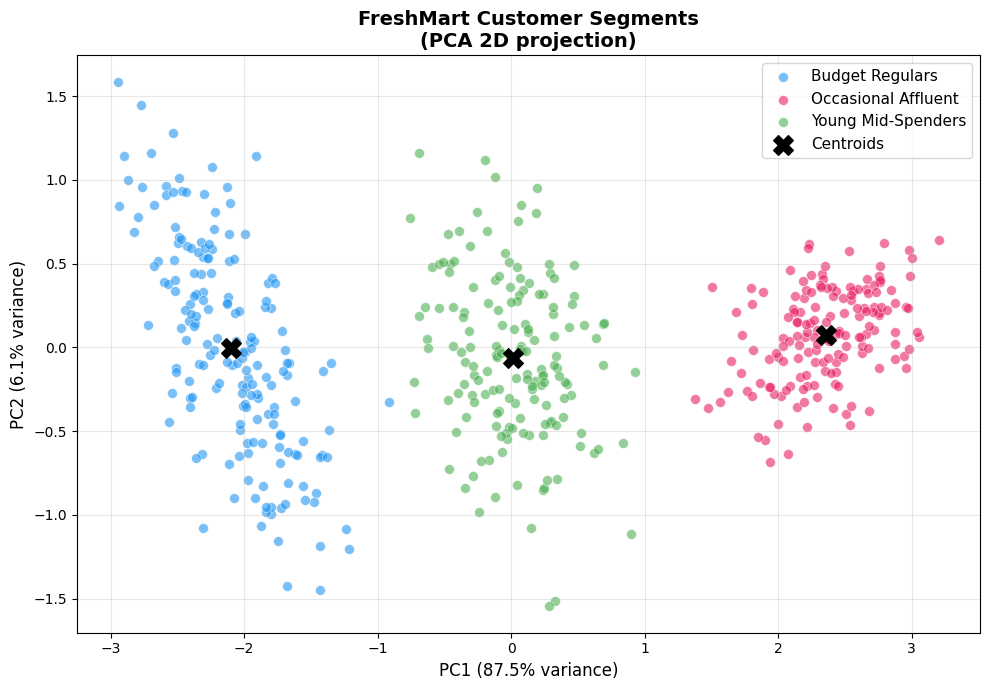

In [12]:
# --- Scatter plot of clusters in 2D ---
# Each dot = one customer. Colour = their cluster assignment.
# Centroids shown as large X markers

fig, ax = plt.subplots(figsize=(10, 7))

colors = {'Budget Regulars': '#2196F3', 
          'Occasional Affluent': '#E91E63', 
          'Young Mid-Spenders': '#4CAF50'}

for segment, color in colors.items():
    mask = df['segment'] == segment
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
               c=color, label=segment, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

# Plot centroids projected to 2D
centroids_2d = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
           c='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('FreshMart Customer Segments\n(PCA 2D projection)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8 — Business Recommendations for Meena

K-Means found 3 natural groups. Now the **human** interprets them and makes business decisions.

In [13]:
# --- Business recommendations ---
recommendations = {
    'Budget Regulars': {
        'profile': 'Low income, modest spending, visits often, small basket',
        'offer': 'Bulk discount coupons, Buy-2-Get-1 on staples, loyalty points boost',
        'reason': 'Price-sensitive but loyal — reward their frequency, help them save'
    },
    'Occasional Affluent': {
        'profile': 'High income, high score, visits rarely, large basket',
        'offer': 'Premium membership, imported goods alerts, free home delivery',
        'reason': 'Come rarely but spend big — give them a reason to come more often'
    },
    'Young Mid-Spenders': {
        'profile': 'Mid income, moderate spending, moderate visits',
        'offer': 'Weekend flash sales, new product launches, app-exclusive deals',
        'reason': 'Young professionals — respond to novelty and digital-first offers'
    }
}

print("=== Marketing Strategy for Meena ===")
for segment, info in recommendations.items():
    count = (df['segment'] == segment).sum()
    print(f"\n{'='*50}")
    print(f"Segment: {segment} ({count} customers)")
    print(f"Profile:  {info['profile']}")
    print(f"Offer:    {info['offer']}")
    print(f"Why:      {info['reason']}")

=== Marketing Strategy for Meena ===

Segment: Budget Regulars (181 customers)
Profile:  Low income, modest spending, visits often, small basket
Offer:    Bulk discount coupons, Buy-2-Get-1 on staples, loyalty points boost
Why:      Price-sensitive but loyal — reward their frequency, help them save

Segment: Occasional Affluent (160 customers)
Profile:  High income, high score, visits rarely, large basket
Offer:    Premium membership, imported goods alerts, free home delivery
Why:      Come rarely but spend big — give them a reason to come more often

Segment: Young Mid-Spenders (159 customers)
Profile:  Mid income, moderate spending, moderate visits
Offer:    Weekend flash sales, new product launches, app-exclusive deals
Why:      Young professionals — respond to novelty and digital-first offers


## Key Weaknesses of K-Means

| Weakness | Why | Fix |
|---|---|---|
| Must choose K upfront | Algorithm needs K before it starts | Elbow + Silhouette method |
| Assumes round clusters | Uses distance to centroid — fails for curved/irregular shapes | DBSCAN (6.3) |
| Sensitive to outliers | Extreme point drags centroid toward it | Remove outliers first, or use DBSCAN |
| Sensitive to scale | Large-scale features dominate distance | StandardScaler mandatory |
| May find local minimum | Random start → trapped in suboptimal solution | K-Means++ init + n_init=10 |
| Different runs → different results | Randomness in initialisation | random_state for reproducibility |

## Summary Table

| Concept | What it means |
|---|---|
| K-Means goal | Minimise inertia — sum of squared distances from each point to its centroid |
| Why mean is optimal | Mean is the provable minimum of sum of squared distances — mathematically guaranteed |
| Convergence | Centroids stop moving. Guaranteed to happen. NOT guaranteed to be globally best. |
| Local minimum | Bad random start → converge to suboptimal clustering |
| K-Means++ | Smart init — spreads starting centroids far apart — reduces local minima |
| n_init=10 | Run 10 times, keep best — another guard against local minima |
| Elbow Method | Plot inertia vs K — bend = good K |
| Silhouette Score | (b-a)/max(a,b) — measures cohesion vs separation — higher is better |
| Cluster labels | Arbitrary numbers — meaning comes from analysing feature means per cluster |
| Why scale | Distance-based algorithm — large-scale features dominate without scaling |
| PCA for visualisation | Compress 4D → 2D keeping max variance — lets us plot clusters visually |

## Practice Task

Ravi works at a Hyderabad gym. He has data on 300 members:
- `age` — member age
- `monthly_fee_paid` — ₹ paid per month
- `visits_per_week` — average visits per week
- `avg_session_duration_min` — average minutes per session

He wants to find natural member groups to design targeted fitness programs.

**Your tasks:**

1. Generate 300 synthetic gym members with 3 natural groups (design the group centres yourself — think: casual, regular, hardcore gym-goers)
2. Scale the features
3. Use Elbow + Silhouette to find the best K
4. Train K-Means with the best K
5. Analyse and name each cluster
6. Visualise with PCA
7. Give Ravi one specific recommendation per group

In [ ]:
# YOUR CODE HERE

# Step 1: Generate data
# Hint: use np.random.multivariate_normal() for each group, then np.vstack()

# Step 2: Scale

# Step 3: Elbow + Silhouette

# Step 4: Train K-Means

# Step 5: Analyse clusters

# Step 6: PCA + scatter plot

# Step 7: Recommendations